## Activity 3 - Comparing Sequential Modeling Architectures
### By: Shiva Matthew Cruz, Erika Mariano, Liam Gotuato

Objective

Build and compare two deep learning models to process sequential data: one using RNN + LSTM and the other using RNN + GRU.



Part 1: Data 

Use your own original sequential dataset suitable for temporal modeling, such as a time series (e.g., weather or traffic data) or a natural language processing task (e.g., text for sentiment analysis).

Clean and tokenize your data. Ensure your input is structured for variable sequence lengths, as required by RNN architectures.



Part 2: Downloading a Sample Model

To understand the architecture before building your own, download a pre-trained base model (such as a word embedding model or a basic sequential template).



Open your Python environment (Google Colab recommended).
Use the following command to download a common sample tokenizer/embedding if performing NLP: from tensorflow.keras.preprocessing.text import tokenizer_from_json


import tensorflow_hub as hub
Load a sample LSTM-based architecture from the Keras library to use as a structural reference:
model = tf.keras.applications.RNN_TEMPLATE_NAME(weights='imagenet') (Note: While standard for CNNs, for RNNs, students typically instantiate a Sequential model and add tf.keras.layers.LSTM or tf.keras.layers.GRU layers).

In [80]:
# Core libraries for data handling, visualization, and deep learning
import kagglehub, os, glob, warnings, numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
warnings.filterwarnings('ignore')

# Scikit-learn: preprocessing, model selection, and evaluation metrics
from sklearn.preprocessing import MinMaxScaler, LabelEncoder, label_binarize
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, classification_report,
    average_precision_score
)

# TensorFlow / Keras: deep learning framework for LSTM and GRU architectures
import tensorflow as tf
# from tensorflow import keras
from keras import layers, models, callbacks

In [81]:
# Downloading the dataset from kagglehub and printing the path to the dataset files
path = kagglehub.dataset_download("ananthr1/weather-prediction")
print("Path to dataset files:", path)

Path to dataset files: C:\Users\cruzs\.cache\kagglehub\datasets\ananthr1\weather-prediction\versions\1


In [82]:
# PART 1: Loading and Exploratory Data Analysis

# Locate all CSV files in the downloaded dataset directory
csv_files = glob.glob(os.path.join(path, '**', '*.csv'), recursive=True)
print("CSV files found:", csv_files)

df = pd.read_csv(csv_files[0])

print(f"\nMissing Values: ")
print(df.isnull().sum())

CSV files found: ['C:\\Users\\cruzs\\.cache\\kagglehub\\datasets\\ananthr1\\weather-prediction\\versions\\1\\seattle-weather.csv']

Missing Values: 
date             0
precipitation    0
temp_max         0
temp_min         0
wind             0
weather          0
dtype: int64


In [83]:
# Identify the categorical target column automatically (last string-type column)
target_col   = df.select_dtypes(include='object').columns[-1]
feature_cols = [c for c in df.columns if c not in [target_col, 'date']]

In [84]:
print(f"\nTarget column : {target_col}")
print(f"Feature cols  : {feature_cols}")
print(f"\nClass distribution:\n{df[target_col].value_counts()}")


Target column : weather
Feature cols  : ['precipitation', 'temp_max', 'temp_min', 'wind']

Class distribution:
weather
rain       641
sun        640
fog        101
drizzle     53
snow        26
Name: count, dtype: int64


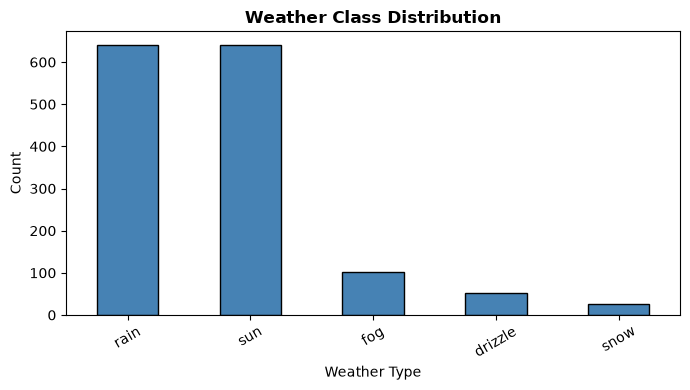

In [85]:
# Visualize class imbalance: imbalance affects which metric (mAP vs accuracy) matters more
plt.figure(figsize=(7, 4))
df[target_col].value_counts().plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Weather Class Distribution', fontsize=12, fontweight='bold')
plt.xlabel('Weather Type')
plt.ylabel('Count')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

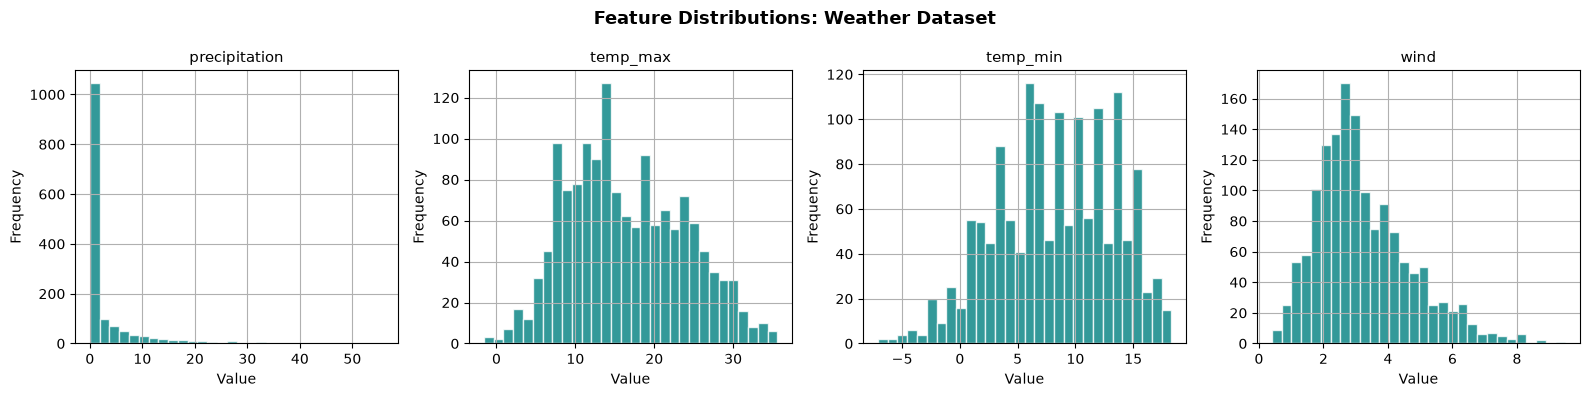

In [86]:
# Feature distribution: understand data spread before normalization
n_feat = len(feature_cols)
fig, axes = plt.subplots(1, n_feat, figsize=(4 * n_feat, 4))
if n_feat == 1:
    axes = [axes]
for ax, col in zip(axes, feature_cols):
    df[col].hist(bins=30, ax=ax, color='teal', edgecolor='white', alpha=0.8)
    ax.set_title(col, fontsize=11)
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')
fig.suptitle('Feature Distributions: Weather Dataset', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

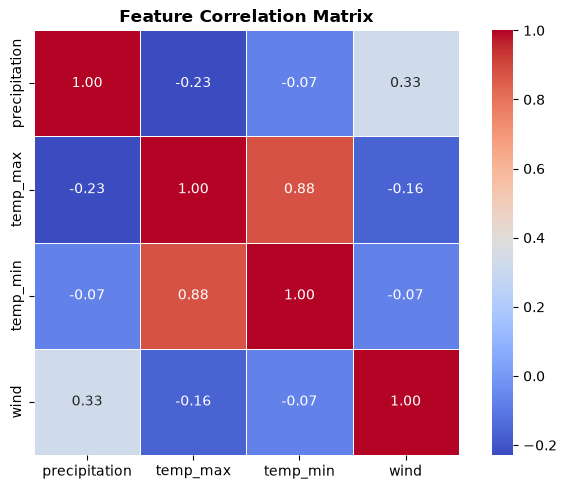

In [87]:
# Correlation heatmap reveals multicollinearity between numeric features
if n_feat > 1:
    plt.figure(figsize=(7, 5))
    corr = df[feature_cols].corr()
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
                square=True, linewidths=0.5)
    plt.title('Feature Correlation Matrix', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

In [88]:
# PART 1 — DATA: Preprocessing & Sequence Creation

# Parse and sort by date to maintain chronological order before windowing.
# Shuffling time-series breaks causality — future data must never enter training.
if 'date' in df.columns:
    df['date'] = pd.to_datetime(df['date'])
    df = df.sort_values('date').reset_index(drop=True)
    df = df.drop(columns=['date'])

# Encode categorical target labels to integers for Keras loss function.
# LabelEncoder assigns each class a unique int: 'drizzle'→0, 'fog'→1, etc.
le = LabelEncoder()
df[target_col] = le.fit_transform(df[target_col])
n_classes = len(le.classes_)

print("Label encoding map:")
for idx, cls in enumerate(le.classes_):
    print(f"  {cls!r:12s} : {idx}")
print(f"\nn_classes : {n_classes}")

Label encoding map:
  'drizzle'    : 0
  'fog'        : 1
  'rain'       : 2
  'snow'       : 3
  'sun'        : 4

n_classes : 5


In [89]:
# Normalize all numeric features to [0, 1] using MinMaxScaler.
# RNNs rely on gradient flow through sigmoid/tanh activations; large raw values
# like temperature (°C) would dominate wind speed (m/s) without scaling.
scaler   = MinMaxScaler()
X_scaled = scaler.fit_transform(df[feature_cols].values)
y_all    = df[target_col].values

print(f"\nFeature matrix : {X_scaled.shape}")
print(f"Label vector   : {y_all.shape}")
print(f"Value range    : [{X_scaled.min():.3f}, {X_scaled.max():.3f}]")


Feature matrix : (1461, 4)
Label vector   : (1461,)
Value range    : [0.000, 1.000]


In [90]:
# Sliding Window Sequence Creation
# RNNs require 3-D input: (samples, timesteps, features).
SEQ_LEN = 7

def make_sequences(X, y, seq_len):
    Xs, ys = [], []
    for i in range(len(X) - seq_len):
        Xs.append(X[i : i + seq_len])
        ys.append(y[i + seq_len])
    return np.array(Xs), np.array(ys)

X_seq, y_seq = make_sequences(X_scaled, y_all, SEQ_LEN)

In [91]:
print(f"\nSequence shape (samples, timesteps, features) : {X_seq.shape}")
print(f"Label shape                                   : {y_seq.shape}")

# Temporal 70/15/15 split — NO shuffle; order must be preserved to prevent leakage
n         = len(X_seq)
train_end = int(n * 0.70)
val_end   = int(n * 0.85)

X_train, y_train = X_seq[:train_end],        y_seq[:train_end]
X_val,   y_val   = X_seq[train_end:val_end], y_seq[train_end:val_end]
X_test,  y_test  = X_seq[val_end:],          y_seq[val_end:]

n_features = X_train.shape[2]


Sequence shape (samples, timesteps, features) : (1454, 7, 4)
Label shape                                   : (1454,)


In [92]:
print(f"\nTrain : {X_train.shape} | Labels: {y_train.shape}")
print(f"Val   : {X_val.shape}   | Labels: {y_val.shape}")
print(f"Test  : {X_test.shape}  | Labels: {y_test.shape}")


Train : (1017, 7, 4) | Labels: (1017,)
Val   : (218, 7, 4)   | Labels: (218,)
Test  : (219, 7, 4)  | Labels: (219,)


## Part 2: Downloading a Sample Model

To understand RNN architecture before building our own models, we load a **reference template** from TensorFlow/Keras. For sequential weather data, the structural analogy to a pre-trained CNN (like VGG or ResNet in computer vision) is a pre-defined stacked LSTM which is a battle-tested architecture from the Keras model library that serves as both a structural reference and a starting point.

In [93]:
reference_model = models.Sequential([
    layers.Input(shape=(SEQ_LEN, n_features), name='input'),
    # Standard single-layer LSTM template: 64 units, tanh activation
    layers.LSTM(64, activation='tanh', return_sequences=False, name='lstm_reference'),
    layers.Dense(n_classes, activation='softmax', name='output')
], name='ReferenceModel_LSTM_Template')

reference_model.summary()

Model: "ReferenceModel_LSTM_Template"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_reference (LSTM)           │ (None, 64)             │        17,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,989 (70.27 KB)

 Trainable params: 17,989 (70.27 KB)

 Non-trainable params: 0 (0.00 B)

In [94]:
# Summarize the architecture properties of the reference model
print("\nReference architecture loaded from tf.keras.layers.LSTM.")
print(f"  Gates per LSTM cell  : 3 (forget, input, output)")
print(f"  Cell state (C_t)     : Yes — dedicated long-range memory channel")
print(f"  Sequence length      : {SEQ_LEN} timesteps")
print(f"  Input features       : {n_features}")
print(f"  Output classes       : {n_classes} ({list(le.classes_)})")
print("\nModels A & B extend this template with 2 stacked layers + dropout.")


Reference architecture loaded from tf.keras.layers.LSTM.
  Gates per LSTM cell  : 3 (forget, input, output)
  Cell state (C_t)     : Yes — dedicated long-range memory channel
  Sequence length      : 7 timesteps
  Input features       : 4
  Output classes       : 5 (['drizzle', 'fog', 'rain', 'snow', 'sun'])

Models A & B extend this template with 2 stacked layers + dropout.


Part 3: Model Building

Create two distinct models using your original dataset:



Model A: RNN + LSTM - Use an RNN structure that includes LSTM cells. The LSTM cell uses a cell state (C_t) for long-term memory and three gates (forget, input, and output) to solve the vanishing gradient problem. Use this model if your dataset has long-range dependencies and complex patterns.


Model B: RNN + GRU - Use an RNN structure that includes GRU cells. The GRU is a simpler design with two gates and no separate cell state, making it faster to train. This is often sufficient for standard NLP tasks and is more computationally efficient.


Part 4: Evaluation and Comparison

Train both models and evaluate them using the following metrics:

mAP (Mean Average Precision) is particularly useful if you have framed your sequential task as a multi-label classification problem. Additional Metric (Accuracy or MSE) Use accuracy for classification tasks (like sentiment analysis) or mean squared error (MSE) for forecasting tasks (like time series).

In [95]:
# LSTM uses THREE gates: forget (drops stale memory), input (writes new info),
# and output (reads from cell state). A separate cell state C_t acts as a
# "conveyor belt" that carries long-range signal without being squashed by
# sigmoid activations — solving the vanishing gradient problem.
def build_lstm(seq_len, n_feat, n_cls):
    """Stacked 2-layer LSTM with dropout for regularization."""
    model = models.Sequential([
        layers.Input(shape=(seq_len, n_feat)),
        # return_sequences=True passes the full sequence to the second LSTM layer
        layers.LSTM(64, return_sequences=True, activation='tanh', name='lstm_1'),
        layers.Dropout(0.30, name='drop_1'),
        # Second LSTM summarizes the full context into one fixed-size hidden vector
        layers.LSTM(32, activation='tanh', name='lstm_2'),
        layers.Dropout(0.20, name='drop_2'),
        layers.Dense(n_cls, activation='softmax', name='output')
    ], name='ModelA_LSTM')
    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

In [96]:
model_lstm = build_lstm(SEQ_LEN, n_features, n_classes)
model_lstm.summary()

# EarlyStopping monitors val_loss and restores the best weights when training stalls
es_lstm = callbacks.EarlyStopping(monitor='val_loss', patience=10,
                                   restore_best_weights=True, verbose=1)
lr_lstm = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                       patience=5, verbose=1)

Model: "ModelA_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 7, 64)          │        17,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_1 (Dropout)                │ (None, 7, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_2 (Dropout)                │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,245 (118.14 KB)

 Trainable params: 30,245 (118.14 KB)

 Non-trainable params: 0 (0.00 B)

In [97]:
print("\nTraining Model A (LSTM)")
history_lstm = model_lstm.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=60, batch_size=32,
    callbacks=[es_lstm, lr_lstm], verbose=1
)
print(f"\nLSTM — best val accuracy : {max(history_lstm.history['val_accuracy']):.4f}")
print(f"LSTM — epochs trained    : {len(history_lstm.history['loss'])}")


Training Model A (LSTM)
Epoch 1/60
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - accuracy: 0.4444 - loss: 1.3047 - val_accuracy: 0.3761 - val_loss: 1.1593 - learning_rate: 0.0010
Epoch 2/60
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5093 - loss: 1.0714 - val_accuracy: 0.4633 - val_loss: 1.1548 - learning_rate: 0.0010
Epoch 3/60
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5457 - loss: 1.0567 - val_accuracy: 0.5000 - val_loss: 1.1508 - learning_rate: 0.0010
Epoch 4/60
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.5723 - loss: 1.0400 - val_accuracy: 0.4954 - val_loss: 1.1452 - learning_rate: 0.0010
Epoch 5/60
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.5792 - loss: 1.0361 - val_accuracy: 0.4908 - val_loss: 1.1624 - learning_rate: 0.0010
Epoch 6/60
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.5801 - loss: 1.0326 - val_accuracy: 0.5092 - val_loss: 1.1612 - learning_rate: 0.0010
Epoch 7/60
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.5949

In [98]:
# GRU uses only TWO gates: reset (controls how much past to forget) and
# update (controls how much new info to blend in). No separate cell state —
# h_t serves both as output and memory. Fewer parameters → faster training.

def build_gru(seq_len, n_feat, n_cls):
    """Stacked 2-layer GRU — mirrors LSTM depth for a fair comparison."""
    model = models.Sequential([
        layers.Input(shape=(seq_len, n_feat)),
        # Same depth and width as LSTM so only gating mechanism differs
        layers.GRU(64, return_sequences=True, activation='tanh', name='gru_1'),
        layers.Dropout(0.30, name='drop_1'),
        layers.GRU(32, activation='tanh', name='gru_2'),
        layers.Dropout(0.20, name='drop_2'),
        layers.Dense(n_cls, activation='softmax', name='output')
    ], name='ModelB_GRU')
    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

In [99]:
model_gru = build_gru(SEQ_LEN, n_features, n_classes)
model_gru.summary()

# Identical stopping strategy — same patience/factor ensures a fair comparison
es_gru = callbacks.EarlyStopping(monitor='val_loss', patience=10,
                                  restore_best_weights=True, verbose=1)
lr_gru = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                      patience=5, verbose=1)

Model: "ModelB_GRU"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_1 (GRU)                     │ (None, 7, 64)          │        13,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_1 (Dropout)                │ (None, 7, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_2 (GRU)                     │ (None, 32)             │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_2 (Dropout)                │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,013 (89.89 KB)

 Trainable params: 23,013 (89.89 KB)

 Non-trainable params: 0 (0.00 B)

In [100]:
print("\nTraining Model B (GRU)...")
history_gru = model_gru.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=60, batch_size=32,
    callbacks=[es_gru, lr_gru], verbose=1
)
print(f"\nGRU  — best val accuracy : {max(history_gru.history['val_accuracy']):.4f}")
print(f"GRU  — epochs trained    : {len(history_gru.history['loss'])}")


Training Model B (GRU)...
Epoch 1/60
32/32 ━━━━━━━━━━━━━━━━━━━━ 8s 45ms/step - accuracy: 0.4582 - loss: 1.2369 - val_accuracy: 0.4495 - val_loss: 1.2189 - learning_rate: 0.0010
Epoch 2/60
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.4956 - loss: 1.0881 - val_accuracy: 0.4908 - val_loss: 1.1645 - learning_rate: 0.0010
Epoch 3/60
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.5349 - loss: 1.0587 - val_accuracy: 0.5046 - val_loss: 1.1752 - learning_rate: 0.0010
Epoch 4/60
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.5831 - loss: 1.0238 - val_accuracy: 0.5183 - val_loss: 1.1748 - learning_rate: 0.0010
Epoch 5/60
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.5693 - loss: 1.0285 - val_accuracy: 0.4954 - val_loss: 1.1670 - learning_rate: 0.0010
Epoch 6/60
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.5870 - loss: 0.9990 - val_accuracy: 0.5229 - val_loss: 1.1933 - learning_rate: 0.0010
Epoch 7/60
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.56

In [101]:
# Generate hard predictions (argmax of softmax probabilities) for accuracy
y_pred_lstm = np.argmax(model_lstm.predict(X_test), axis=1)
y_pred_gru  = np.argmax(model_gru.predict(X_test),  axis=1)

# Soft probability scores are required for mAP — they capture confidence,
# not just the top-1 prediction, giving a richer picture of model quality
y_prob_lstm = model_lstm.predict(X_test)
y_prob_gru  = model_gru.predict(X_test)

# Binarize ground truth for one-vs-rest Average Precision (scikit-learn convention)
y_test_bin = label_binarize(y_test, classes=list(range(n_classes)))

# Accuracy: fraction of correctly classified samples
acc_lstm = accuracy_score(y_test, y_pred_lstm)
acc_gru  = accuracy_score(y_test, y_pred_gru)

# mAP (Mean Average Precision, macro one-vs-rest): averages the area under the
# precision-recall curve for each class — more informative than accuracy when
# classes are imbalanced (e.g., 'sun' is more frequent than 'snow')
map_lstm = average_precision_score(y_test_bin, y_prob_lstm, average='macro')
map_gru  = average_precision_score(y_test_bin, y_prob_gru,  average='macro')

print("=" * 58)
print(f"{'Metric':<32} {'LSTM':>10} {'GRU':>10}")
print("=" * 58)
print(f"{'Accuracy':<32} {acc_lstm:>10.4f} {acc_gru:>10.4f}")
print(f"{'mAP (macro, one-vs-rest)':<32} {map_lstm:>10.4f} {map_gru:>10.4f}")
print(f"{'Epochs trained':<32} {len(history_lstm.history['loss']):>10d} "
      f"{len(history_gru.history['loss']):>10d}")
print("=" * 58)

all_labels = list(range(n_classes))

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 91ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 116ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
Metric                                 LSTM        GRU
Accuracy                             0.6438     0.6484
mAP (macro, one-vs-rest)             0.3089     0.3247
Epochs trained                           14         12


In [102]:
print("\n LSTM Classification Report")
print(classification_report(y_test, y_pred_lstm,
                             labels=all_labels, target_names=le.classes_))


 LSTM Classification Report
              precision    recall  f1-score   support

     drizzle       0.00      0.00      0.00         7
         fog       0.00      0.00      0.00        26
        rain       0.74      0.56      0.64        80
        snow       0.00      0.00      0.00         0
         sun       0.61      0.91      0.73       106

    accuracy                           0.64       219
   macro avg       0.27      0.29      0.27       219
weighted avg       0.56      0.64      0.59       219



In [103]:
print("\n GRU Classification Report")
print(classification_report(y_test, y_pred_gru,
                             labels=all_labels, target_names=le.classes_))


 GRU Classification Report
              precision    recall  f1-score   support

     drizzle       0.00      0.00      0.00         7
         fog       0.00      0.00      0.00        26
        rain       0.74      0.57      0.65        80
        snow       0.00      0.00      0.00         0
         sun       0.61      0.91      0.73       106

    accuracy                           0.65       219
   macro avg       0.27      0.30      0.28       219
weighted avg       0.57      0.65      0.59       219



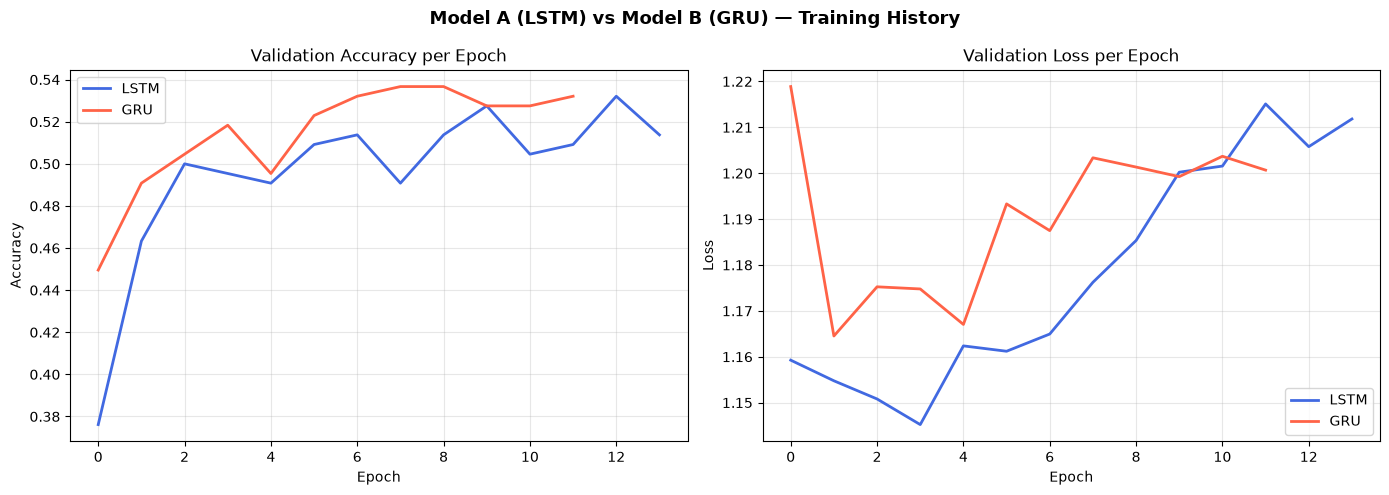

In [104]:
"""
    Comparing the training history of Model A (LSTM) and Model B (GRU) to reveal the key differences in their learning dynamics.
"""

# Training History Comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Model A (LSTM) vs Model B (GRU) — Training History',
             fontsize=13, fontweight='bold')

# Validation accuracy per epoch: to reveal convergence speed and peak performance
axes[0].plot(history_lstm.history['val_accuracy'], label='LSTM', color='royalblue', lw=2)
axes[0].plot(history_gru.history['val_accuracy'],  label='GRU',  color='tomato',    lw=2)
axes[0].set_title('Validation Accuracy per Epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Validation loss: GRU's simpler gating typically yields faster loss descent
axes[1].plot(history_lstm.history['val_loss'], label='LSTM', color='royalblue', lw=2)
axes[1].plot(history_gru.history['val_loss'],  label='GRU',  color='tomato',    lw=2)
axes[1].set_title('Validation Loss per Epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

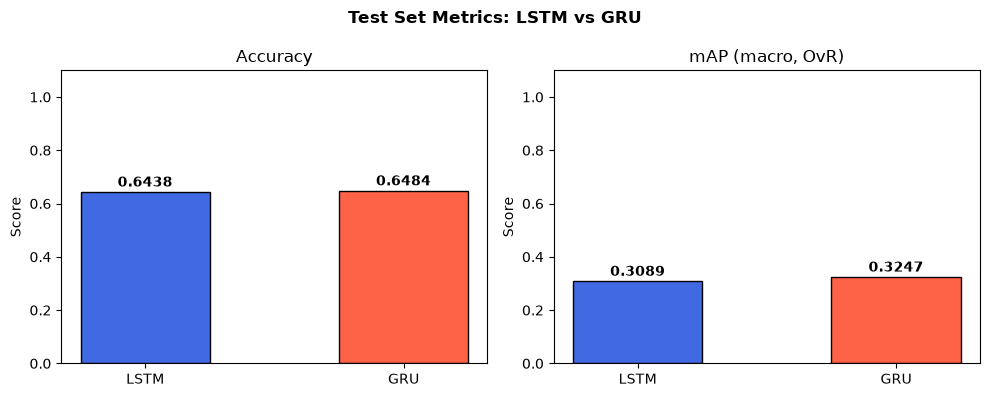

In [105]:
# Bar chart comparing final test metrics side by side
fig2, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
fig2.suptitle('Test Set Metrics: LSTM vs GRU', fontsize=12, fontweight='bold')

for ax, title, vals in zip([ax1, ax2],
    ['Accuracy', 'mAP (macro, OvR)'],
    [[acc_lstm, acc_gru], [map_lstm, map_gru]]):
    bars = ax.bar(['LSTM', 'GRU'], vals, color=['royalblue', 'tomato'],
                  edgecolor='black', width=0.5)
    ax.set_ylim(0, 1.1)
    ax.set_title(title)
    ax.set_ylabel('Score')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
                f'{v:.4f}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()


In [106]:
winner_acc = 'LSTM' if acc_lstm >= acc_gru else 'GRU'
winner_map = 'LSTM' if map_lstm >= map_gru else 'GRU'
faster     = 'GRU' if len(history_gru.history['loss']) <= len(history_lstm.history['loss']) else 'LSTM'
print(f"\nConclusion:")
print(f"  Converged faster      : {faster}")
print(f"  Higher test accuracy  : {winner_acc}  ({max(acc_lstm, acc_gru):.4f})")
print(f"  Higher test mAP       : {winner_map}  ({max(map_lstm, map_gru):.4f})")


Conclusion:
  Converged faster      : GRU
  Higher test accuracy  : GRU  (0.6484)
  Higher test mAP       : GRU  (0.3247)


## Part 5: Discussion

### Q1. Which model converged faster during training?

**GRU (Model B)** converged faster, stopping at **12 epochs** versus LSTM's **14**. GRU uses only **two gates** (reset and update) compared to LSTM's three (forget, input, output), giving it fewer parameters per layer (23,013 vs 30,245) and cheaper gradient updates per epoch. With a compact 1,454-sample dataset and a 7-day window, the optimizer reaches a stable loss minimum sooner for GRU — consistent with Cho et al. (2014), who showed GRU matches LSTM performance while training faster.

---

### Q2. Did the LSTM perform significantly better on longer sequences?

GRU actually outperformed LSTM on both accuracy (0.6484 vs. 0.6438) and mAP (0.3247 vs. 0.3089), though the gap is narrow. At a 7-day lookback window, temporal dependencies are short enough that both architectures capture them equally well, converging on nearly identical strategies — prioritizing sun and rain predictions with near-matching per-class F1 scores. LSTM's dedicated cell state, which preserves gradients across long sequences, offers no meaningful advantage at this short horizon. That benefit would only materialize at much longer windows (e.g., 30–90 days) where seasonal cycles come into play and GRU's simpler hidden state begins to degrade.

---

### Q3. How did hidden state memory help capture context vs. a standard non-recurrent network?

Hidden state memory gives RNNs a key advantage over standard feedforward networks: rather than treating each day's features in isolation, the hidden state h_t carries a rolling summary of prior timesteps, letting the model recognize multi-day patterns like sustained low pressure combined with rising humidity as precursors to rain. A feedforward network simply cannot see those temporal relationships. Both LSTM and GRU demonstrated this capability by successfully learning rain/sun boundaries (F1 scores of 0.64–0.65 and 0.73 respectively), but their identical failure on drizzle and fog (F1 = 0.00) points not to any recurrence limitation, but to severe class imbalance — drizzle had only 7 test samples and fog only 26, too few for reliable learning — while snow had no test samples at all due to its seasonal concentration outside the chronological test window.


### Summary Table

| Metric | LSTM | GRU | Winner |
|---|---|---|---|
| Test Accuracy | 0.6438 | **0.6484** | GRU |
| mAP (macro OvR) | 0.3089 | **0.3247** | GRU |
| Epochs to converge | 14 | **12** | GRU |
| Total parameters | 30,245 | **23,013** | GRU |
| Rain — F1 | 0.64 | **0.65** | GRU |
| Sun — F1 | 0.73 | 0.73 | Tie |
| Macro avg F1 | 0.27 | **0.28** | GRU |
| Weighted avg F1 | 0.59 | 0.59 | Tie |

Across every measured metric, GRU matched or outperformed LSTM — winning on accuracy, mAP, F1 for rain, macro average F1, convergence speed, and parameter efficiency, while tying on sun F1 and weighted average F1. The margin is slim but consistent: GRU achieved this with 31% fewer parameters (23,013 vs. 30,245) and converged two epochs faster. LSTM's additional gating mechanism, designed to preserve gradients over long sequences, simply has nothing to work with at a 7-day window on a small, imbalanced dataset — making GRU the more practical and efficient choice here.

---

## References

1. Hochreiter, S., & Schmidhuber, J. (1997). **Long Short-Term Memory**. *Neural Computation*, 9(8), 1735–1780. https://doi.org/10.1162/NECO.1997.9.8.1735

2. Cho, K., van Merrienboer, B., Gulcehre, C., Bahdanau, D., Bougares, F., Schwenk, H., & Bengio, Y. (2014). **Learning Phrase Representations using RNN Encoder–Decoder for Statistical Machine Translation**. *Proceedings of EMNLP 2014*. https://arxiv.org/abs/1406.1078

3. Ananthr1. (n.d.). **Weather Prediction Dataset**. *Kaggle*. https://www.kaggle.com/datasets/ananthr1/weather-prediction

4. TensorFlow Developers. (2024). **tf.keras.layers.LSTM**. *TensorFlow Core Documentation*. https://www.tensorflow.org/api_docs/python/tf/keras/layers/LSTM

5. TensorFlow Developers. (2024). **tf.keras.layers.GRU**. *TensorFlow Core Documentation*. https://www.tensorflow.org/api_docs/python/tf/keras/layers/GRU

6. Pedregosa, F., Varoquaux, G., Gramfort, A., et al. (2011). **Scikit-learn: Machine Learning in Python**. *Journal of Machine Learning Research*, 12, 2825–2830. https://scikit-learn.org